In [1]:
!pip install pandas numpy lightgbm catboost scikit-learn matplotlib joblib

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.8.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 49.2 MB/s eta 0:00:03
   --- ------------------------------------ 8.4/100.2 MB 23.6 MB/s eta 0:00:04
   --- ------------------------------------ 10.0/100.2 MB 15.9 MB/s eta 0:00:06
   ----- ------------------------

# 🎮 Draft.AI — LoL Match Outcome Prediction Model

## Training Pipeline

| Component | Technology |
|---|---|
| **Data Wrangling** | Pandas |
| **Models** | LightGBM + CatBoost |
| **Calibration** | Scikit-Learn (Isotonic Regression) |
| **Data** | Oracle's Elixir LoL Esports (2023–2026) |
| **Target** | Blue-side win probability from champion draft |

---

In [2]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, log_loss, brier_score_loss,
    roc_auc_score, classification_report
)
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
import matplotlib.pyplot as plt
import json
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


## 1. Data Loading

Loading recent years (2023–2026) of Oracle’s Elixir LoL esports match data.
Each CSV has **12 rows per game**: 5 player rows per side + 1 team summary row per side.

In [4]:
DATA_DIR = '../Dataset'
YEARS = [2023, 2024, 2025, 2026]

dfs = []
for year in YEARS:
    path = os.path.join(DATA_DIR, f'{year}_LoL_esports_match_data_from_OraclesElixir.csv')
    
    print("Loading:", path)
    
    df = pd.read_csv(path, low_memory=False)
    print(f'✅ {year}: {len(df):>10,} rows | {df["gameid"].nunique():>7,} games')
    dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)
print(f'\n📊 Total: {len(raw_df):,} rows | {raw_df["gameid"].nunique():,} unique games')

Loading: .\2023_LoL_esports_match_data_from_OraclesElixir.csv
✅ 2023:    133,272 rows |  11,106 games
Loading: .\2024_LoL_esports_match_data_from_OraclesElixir.csv
✅ 2024:    122,304 rows |  10,192 games
Loading: .\2025_LoL_esports_match_data_from_OraclesElixir.csv
✅ 2025:    120,456 rows |  10,038 games
Loading: .\2026_LoL_esports_match_data_from_OraclesElixir.csv
✅ 2026:     70,092 rows |   5,841 games

📊 Total: 446,124 rows | 37,177 unique games


## 2. Data Wrangling with Pandas

**Key steps:**
1. Filter to complete data only
2. Extract player-level rows (position ≠ 'team') 
3. Pivot to one row per game with champion picks per role per side
4. Clean champion names and handle missing data

In [5]:
# -----------------------------------------------------------
# 2a. Filter to complete data
# -----------------------------------------------------------
raw_df = raw_df[raw_df['datacompleteness'] == 'complete'].copy()
print(f'After filtering complete data: {raw_df["gameid"].nunique():,} games')

# -----------------------------------------------------------
# 2b. Extract player rows only (not team summaries)
# -----------------------------------------------------------
player_df = raw_df[raw_df['position'] != 'team'].copy()
player_df['position'] = player_df['position'].str.lower()
player_df = player_df[player_df['position'].isin(['top', 'jng', 'mid', 'bot', 'sup'])]
player_df = player_df.dropna(subset=['champion'])

# -----------------------------------------------------------
# 2c. Remove games with duplicate role assignments
# -----------------------------------------------------------
player_df['role_side'] = player_df['side'].str.lower() + '_' + player_df['position']
dupes = player_df.groupby(['gameid', 'role_side']).size()
dupe_games = dupes[dupes > 1].reset_index()['gameid'].unique()
print(f'Games with duplicate role assignments (removed): {len(dupe_games)}')
player_df = player_df[~player_df['gameid'].isin(dupe_games)]

# -----------------------------------------------------------
# 2d. Pivot: one row per game, columns = role_side, values = champion
# -----------------------------------------------------------
draft_pivot = player_df.pivot_table(
    index='gameid',
    columns='role_side',
    values='champion',
    aggfunc='first'
).reset_index()

# Get context from blue-side player rows
blue_context = player_df[player_df['side'] == 'Blue'].groupby('gameid').agg({
    'result': 'first',
    'patch': 'first',
    'league': 'first',
    'playoffs': 'first',
    'year': 'first'
}).reset_index()

games_df = draft_pivot.merge(blue_context, on='gameid', how='inner')

# Define role columns
ROLE_COLS = [
    'blue_top', 'blue_jng', 'blue_mid', 'blue_bot', 'blue_sup',
    'red_top',  'red_jng',  'red_mid',  'red_bot',  'red_sup'
]

# Drop games with any missing champion pick
games_df = games_df.dropna(subset=ROLE_COLS)
games_df['result'] = games_df['result'].astype(int)

print(f'\n✅ Final dataset: {len(games_df):,} games')
print(f'📊 Blue side win rate: {games_df["result"].mean():.4f} ({games_df["result"].mean()*100:.1f}%)')
print(f'📊 Years: {sorted(games_df["year"].unique())}')
print(f'📊 Leagues: {games_df["league"].nunique()} unique')
print(f'📊 Unique champions: {pd.concat([games_df[c] for c in ROLE_COLS]).nunique()}')
games_df.head()

After filtering complete data: 32,786 games
Games with duplicate role assignments (removed): 0

✅ Final dataset: 32,786 games
📊 Blue side win rate: 0.5314 (53.1%)
📊 Years: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
📊 Leagues: 74 unique
📊 Unique champions: 172


,gameid,blue_bot,blue_jng,blue_mid,blue_sup,blue_top,red_bot,red_jng,red_mid,red_sup,red_top,result,patch,league,playoffs,year
0,ESPORTSTMNT01_3286841,Jhin,Wukong,Syndra,Seraphine,K'Sante,Varus,Xin Zhao,Lux,Karma,Fiora,0,13.01,NEXO,0,2023
1,ESPORTSTMNT01_3286882,Varus,Maokai,Kassadin,Nautilus,Aatrox,Zeri,Wukong,Syndra,Yuumi,Poppy,1,13.01,NEXO,0,2023
2,ESPORTSTMNT01_3286910,Sivir,Kindred,Syndra,Heimerdinger,Ornn,Varus,Maokai,Ryze,Jhin,K'Sante,0,13.01,NEXO,0,2023
3,ESPORTSTMNT01_3286935,Varus,Vi,Ryze,Nautilus,Gnar,Zeri,Maokai,Tristana,Yuumi,Irelia,0,13.01,NEXO,0,2023
4,ESPORTSTMNT01_3287811,Ashe,Graves,Galio,Karma,Fiora,Sivir,Bel'Veth,Lissandra,Nautilus,Gragas,1,13.01,NEXO,0,2023


## 3. Exploratory Data Analysis

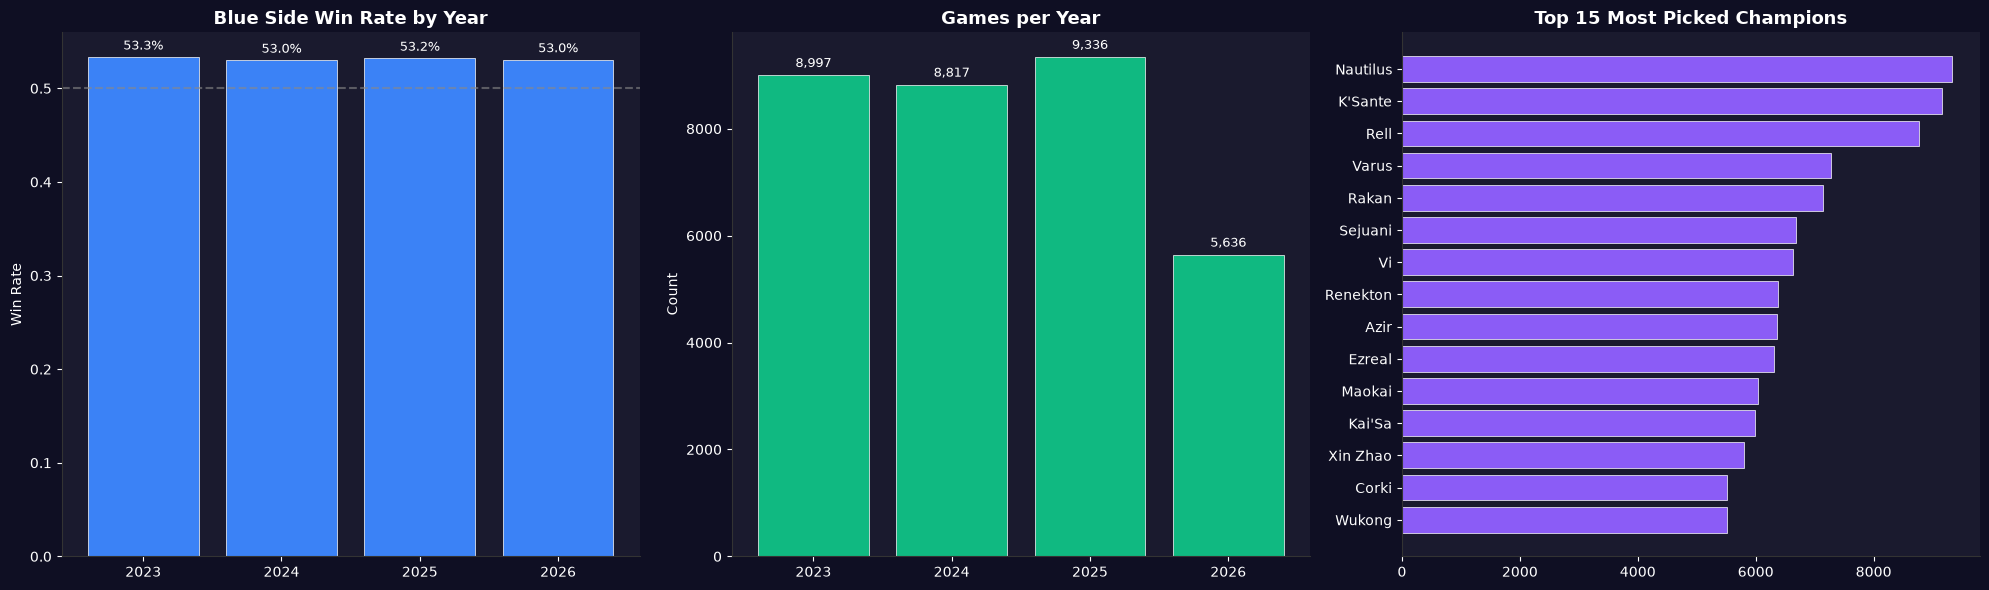

✅ EDA plots saved


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Blue side win rate by year ---
yearly = games_df.groupby('year')['result'].agg(['mean', 'count'])
colors_bar = ['#3b82f6' if v >= 0.5 else '#ef4444' for v in yearly['mean']]
axes[0].bar(yearly.index.astype(str), yearly['mean'], color=colors_bar, edgecolor='white', linewidth=0.5)
axes[0].axhline(y=0.5, color='#888', linestyle='--', alpha=0.6)
axes[0].set_title('Blue Side Win Rate by Year', fontweight='bold', color='white', fontsize=13)
axes[0].set_ylabel('Win Rate', color='white')
for i, (yr, row) in enumerate(yearly.iterrows()):
    axes[0].text(i, row['mean'] + 0.005, f'{row["mean"]:.1%}', ha='center', va='bottom', color='white', fontsize=9)

# --- Games per year ---
axes[1].bar(yearly.index.astype(str), yearly['count'], color='#10b981', edgecolor='white', linewidth=0.5)
axes[1].set_title('Games per Year', fontweight='bold', color='white', fontsize=13)
axes[1].set_ylabel('Count', color='white')
for i, (yr, row) in enumerate(yearly.iterrows()):
    axes[1].text(i, row['count'] + 100, f'{int(row["count"]):,}', ha='center', va='bottom', color='white', fontsize=9)

# --- Top 15 most picked champions ---
all_picks = pd.concat([games_df[c] for c in ROLE_COLS])
top_champs = all_picks.value_counts().head(15)
axes[2].barh(top_champs.index[::-1], top_champs.values[::-1], color='#8b5cf6', edgecolor='white', linewidth=0.5)
axes[2].set_title('Top 15 Most Picked Champions', fontweight='bold', color='white', fontsize=13)

fig.patch.set_facecolor('#0f0f23')
for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('#333')
    ax.spines['left'].set_color('#333')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight', facecolor='#0f0f23')
plt.show()
print('✅ EDA plots saved')

## 4. Feature Engineering

**Two encoding approaches:**

| Approach | Use Case | Description |
|---|---|---|
| **Label Encoding** | LightGBM & CatBoost | 10 integer-coded categorical features (native handling) |
| **One-Hot Encoding** | Interpretability & export | Binary `blue_has_<champ>` / `red_has_<champ>` features |

In [7]:
# ============================================================
# 4a. Label Encoding (for tree models with native categorical)
# ============================================================
le = LabelEncoder()
all_champions = pd.concat([games_df[c] for c in ROLE_COLS]).dropna().unique()
le.fit(all_champions)

games_enc = games_df.copy()
ENCODED_COLS = []
for col in ROLE_COLS:
    enc_col = f'{col}_enc'
    games_enc[enc_col] = le.transform(games_enc[col])
    ENCODED_COLS.append(enc_col)

print(f'✅ Label encoded {len(le.classes_)} unique champions')
print(f'   Features: {ENCODED_COLS}')

# ============================================================
# 4b. One-Hot Encoding (for interpretability & frontend export)
# ============================================================
blue_role_cols = [c for c in ROLE_COLS if c.startswith('blue_')]
red_role_cols  = [c for c in ROLE_COLS if c.startswith('red_')]

for champ in le.classes_:
    games_enc[f'bh_{champ}'] = games_enc[blue_role_cols].eq(champ).any(axis=1).astype(int)
    games_enc[f'rh_{champ}'] = games_enc[red_role_cols].eq(champ).any(axis=1).astype(int)

ONEHOT_COLS = [c for c in games_enc.columns if c.startswith('bh_') or c.startswith('rh_')]
print(f'✅ One-hot encoded: {len(ONEHOT_COLS)} binary features')

✅ Label encoded 172 unique champions
   Features: ['blue_top_enc', 'blue_jng_enc', 'blue_mid_enc', 'blue_bot_enc', 'blue_sup_enc', 'red_top_enc', 'red_jng_enc', 'red_mid_enc', 'red_bot_enc', 'red_sup_enc']
✅ One-hot encoded: 344 binary features


## 5. Train / Test Split

**Temporal split** to simulate real-world usage:
- **Train**: 2023–2025
- **Test**: 2026

In [8]:
train_mask = games_enc['year'] < 2026
test_mask  = games_enc['year'] >= 2026

X_train_cat = games_enc.loc[train_mask, ENCODED_COLS].copy()
X_test_cat  = games_enc.loc[test_mask,  ENCODED_COLS].copy()

X_train_oh = games_enc.loc[train_mask, ONEHOT_COLS].copy()
X_test_oh  = games_enc.loc[test_mask,  ONEHOT_COLS].copy()

y_train = games_enc.loc[train_mask, 'result'].copy()
y_test  = games_enc.loc[test_mask,  'result'].copy()

print(f'📊 Train: {len(X_train_cat):,} games (2023–2025)')
print(f'📊 Test:  {len(X_test_cat):,} games (2026)')
print(f'📊 Train blue WR: {y_train.mean():.4f} | Test blue WR: {y_test.mean():.4f}')

📊 Train: 27,150 games (2023–2025)
📊 Test:  5,636 games (2026)
📊 Train blue WR: 0.5316 | Test blue WR: 0.5303


## 6. Model Training — LightGBM

LightGBM with **native categorical feature support**. The model learns complex champion interactions through gradient-boosted decision trees without needing one-hot encoding.

In [9]:
lgb_train_ds = lgb.Dataset(
    X_train_cat, label=y_train,
    categorical_feature=ENCODED_COLS,
    free_raw_data=False
)
lgb_val_ds = lgb.Dataset(
    X_test_cat, label=y_test,
    categorical_feature=ENCODED_COLS,
    reference=lgb_train_ds,
    free_raw_data=False
)

lgb_params = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'boosting_type': 'gbdt',
    'num_leaves': 64,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 50,
    'verbose': -1,
    'seed': 42
}

lgb_model = lgb.train(
    lgb_params,
    lgb_train_ds,
    num_boost_round=1000,
    valid_sets=[lgb_train_ds, lgb_val_ds],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(100)
    ]
)

lgb_pred_train = lgb_model.predict(X_train_cat)
lgb_pred_test  = lgb_model.predict(X_test_cat)

print(f'\n✅ LightGBM Results:')
print(f'   Train AUC:     {roc_auc_score(y_train, lgb_pred_train):.4f}')
print(f'   Test AUC:      {roc_auc_score(y_test, lgb_pred_test):.4f}')
print(f'   Test Accuracy: {accuracy_score(y_test, (lgb_pred_test > 0.5).astype(int)):.4f}')
print(f'   Test Log Loss: {log_loss(y_test, lgb_pred_test):.4f}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[33]	train's binary_logloss: 0.636107	train's auc: 0.78898	valid's binary_logloss: 0.688138	valid's auc: 0.545425

✅ LightGBM Results:
   Train AUC:     0.7890
   Test AUC:      0.5454
   Test Accuracy: 0.5399
   Test Log Loss: 0.6881


## 7. Model Training — CatBoost

CatBoost excels at handling categorical features with **target-based encoding** and **ordered boosting**, which helps prevent target leakage on high-cardinality categoricals like champion names.

In [10]:
cat_feature_indices = list(range(len(ENCODED_COLS)))

cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=100,
    eval_metric='AUC',
    early_stopping_rounds=50,
    cat_features=cat_feature_indices
)

cb_model.fit(
    X_train_cat, y_train,
    eval_set=(X_test_cat, y_test),
    use_best_model=True
)

cb_pred_train = cb_model.predict_proba(X_train_cat)[:, 1]
cb_pred_test  = cb_model.predict_proba(X_test_cat)[:, 1]

print(f'\n✅ CatBoost Results:')
print(f'   Train AUC:     {roc_auc_score(y_train, cb_pred_train):.4f}')
print(f'   Test AUC:      {roc_auc_score(y_test, cb_pred_test):.4f}')
print(f'   Test Accuracy: {accuracy_score(y_test, (cb_pred_test > 0.5).astype(int)):.4f}')
print(f'   Test Log Loss: {log_loss(y_test, cb_pred_test):.4f}')

0:	test: 0.5259223	best: 0.5259223 (0)	total: 272ms	remaining: 4m 32s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.540272777
bestIteration = 39

Shrink model to first 40 iterations.

✅ CatBoost Results:
   Train AUC:     0.5870
   Test AUC:      0.5403
   Test Accuracy: 0.5335
   Test Log Loss: 0.6893


## 8. Ensemble + Probability Calibration (Scikit-Learn)

1. **Ensemble**: Average LightGBM and CatBoost predictions
2. **Calibration**: Apply **isotonic regression** via `CalibratedClassifierCV` to ensure predicted probabilities are well-calibrated (a 60% prediction ≈ 60% actual win rate)

In [ ]:

# -----------------------------------------------------------
# Ensemble + SAFE Calibration (FULL FIXED PIPELINE)
# -----------------------------------------------------------

from lightgbm import LGBMClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss, brier_score_loss

# -----------------------------------------------------------
# 0. FIX LIGHTGBM MODEL (IMPORTANT CHANGE)
# -----------------------------------------------------------

# REPLACE YOUR OLD lgb_model (Booster) WITH THIS
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

# CatBoost should already be sklearn-style
# cb_model = CatBoostClassifier(...)

# -----------------------------------------------------------
# 1. Train/Validation split for calibration
# -----------------------------------------------------------

X_cal_fit, X_cal_val, y_cal_fit, y_cal_val = train_test_split(
    X_train_cat, y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

# -----------------------------------------------------------
# 2. Train models (SKLEARN STYLE)
# -----------------------------------------------------------

lgb_model.fit(X_cal_fit, y_cal_fit, categorical_feature=ENCODED_COLS)
cb_model.fit(X_cal_fit, y_cal_fit)

# -----------------------------------------------------------
# 3. Ensemble predictions (validation set)
# -----------------------------------------------------------

lgb_cal = lgb_model.predict_proba(X_cal_val)[:, 1]
cb_cal  = cb_model.predict_proba(X_cal_val)[:, 1]

ens_cal = (lgb_cal + cb_cal) / 2

print('📊 Ensemble (before calibration):')
print(f'   AUC: {roc_auc_score(y_cal_val, ens_cal):.4f}')
print(f'   Acc: {accuracy_score(y_cal_val, (ens_cal > 0.5).astype(int)):.4f}')
print(f'   LogLoss: {log_loss(y_cal_val, ens_cal):.4f}')
print(f'   Brier: {brier_score_loss(y_cal_val, ens_cal):.4f}')

# -----------------------------------------------------------
# 4. SAFE Isotonic Calibration (NO sklearn wrapper)
# -----------------------------------------------------------

calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(ens_cal, y_cal_val)

# -----------------------------------------------------------
# 5. Test predictions
# -----------------------------------------------------------

lgb_test = lgb_model.predict_proba(X_test_cat)[:, 1]
cb_test  = cb_model.predict_proba(X_test_cat)[:, 1]

ens_test = (lgb_test + cb_test) / 2

cal_pred_test = calibrator.transform(ens_test)

# -----------------------------------------------------------
# 6. Final evaluation
# -----------------------------------------------------------

print(f'\n📊 Calibrated Ensemble:')
print(f'   Test AUC:      {roc_auc_score(y_test, cal_pred_test):.4f}')
print(f'   Test Accuracy: {accuracy_score(y_test, (cal_pred_test > 0.5).astype(int)):.4f}')
print(f'   Test Log Loss: {log_loss(y_test, cal_pred_test):.4f}')
print(f'   Test Brier:    {brier_score_loss(y_test, cal_pred_test):.4f}')

0:	total: 109ms	remaining: 1m 48s
100:	total: 12.2s	remaining: 1m 48s


## 9. Model Evaluation & Calibration Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# --- 1. Calibration Curve ---
model_preds = [
    ('LightGBM',   lgb_pred_test, '#3b82f6'),
    ('CatBoost',   cb_pred_test,  '#10b981'),
    ('Ensemble',   ens_test, '#8b5cf6'),
    ('Calibrated', cal_pred_test, '#f59e0b'),
]
for name, preds, color in model_preds:
    prob_true, prob_pred = calibration_curve(y_test, preds, n_bins=10, strategy='uniform')
    axes[0].plot(prob_pred, prob_true, marker='o', label=name, linewidth=2, color=color)
axes[0].plot([0, 1], [0, 1], 'w--', alpha=0.4, label='Perfect')
axes[0].set_title('Calibration Curves', fontweight='bold', color='white', fontsize=13)
axes[0].set_xlabel('Mean Predicted Probability', color='white')
axes[0].set_ylabel('Fraction of Positives', color='white')
axes[0].legend(fontsize=9)

# --- 2. Prediction Distribution ---
axes[1].hist(cal_pred_test[y_test == 1], bins=30, alpha=0.65, label='Blue Wins', color='#3b82f6')
axes[1].hist(cal_pred_test[y_test == 0], bins=30, alpha=0.65, label='Blue Losses', color='#ef4444')
axes[1].set_title('Calibrated Prediction Distribution', fontweight='bold', color='white', fontsize=13)
axes[1].set_xlabel('Predicted Blue Win Probability', color='white')
axes[1].set_ylabel('Count', color='white')
axes[1].legend(fontsize=9)

# --- 3. Model AUC Comparison ---
names  = [m[0] for m in model_preds]
aucs   = [roc_auc_score(y_test, m[1]) for m in model_preds]
colors = [m[2] for m in model_preds]
bars = axes[2].barh(names, aucs, color=colors, edgecolor='white', linewidth=0.5)
axes[2].set_xlim(min(aucs) - 0.01, max(aucs) + 0.01)
for bar, auc_val in zip(bars, aucs):
    axes[2].text(auc_val + 0.001, bar.get_y() + bar.get_height()/2, f'{auc_val:.4f}',
                 va='center', color='white', fontsize=10, fontweight='bold')
axes[2].set_title('Model AUC-ROC Comparison', fontweight='bold', color='white', fontsize=13)
axes[2].set_xlabel('AUC-ROC', color='white')

fig.patch.set_facecolor('#0f0f23')
for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight', facecolor='#0f0f23')
plt.show()

# --- Summary Table ---
print('\n' + '='*60)
print(f'{"Model":<15} {"AUC":>8} {"Accuracy":>10} {"Log Loss":>10} {"Brier":>8}')
print('-'*60)
for name, preds, _ in model_preds:
    acc   = accuracy_score(y_test, (preds > 0.5).astype(int))
    auc   = roc_auc_score(y_test, preds)
    ll    = log_loss(y_test, preds)
    brier = brier_score_loss(y_test, preds)
    print(f'{name:<15} {auc:>8.4f} {acc:>10.4f} {ll:>10.4f} {brier:>8.4f}')
print('='*60)

## 10. Export Model for React Frontend

Export champion win-contribution scores and model artifacts:

1. **Per-champion value scores** (smoothed with Bayesian prior) for each role & side
2. **Overall champion stats** (pick counts, win rates)
3. **Model artifacts** (pickle files for potential Python API)
4. **JSON file** for the React Draft Simulator

In [ ]:
base_rate = float(y_train.mean())
SMOOTHING = 20  # Bayesian prior strength

# -----------------------------------------------------------
# 10a. Champion value per role per side
# -----------------------------------------------------------
champion_values = {}

for role_col in ROLE_COLS:
    side, role = role_col.split('_', 1)
    champ_wr = games_df.groupby(role_col)['result'].agg(['mean', 'count'])
    champ_wr.columns = ['win_rate', 'games']
    champ_wr = champ_wr[champ_wr['games'] >= 5]  # minimum sample size

    for champ, row in champ_wr.iterrows():
        smoothed = (row['win_rate'] * row['games'] + base_rate * SMOOTHING) / (row['games'] + SMOOTHING)
        champion_values.setdefault(champ, {}).setdefault(side, {})[role] = {
            'win_rate': round(float(smoothed), 4),
            'raw_win_rate': round(float(row['win_rate']), 4),
            'games': int(row['games']),
            'value': round(float(smoothed - base_rate), 4)
        }

# -----------------------------------------------------------
# 10b. Overall champion stats
# -----------------------------------------------------------
champion_stats = {}
all_champs_set = set()
for col in ROLE_COLS:
    all_champs_set.update(games_df[col].unique())

blue_cols = [c for c in ROLE_COLS if c.startswith('blue_')]
red_cols  = [c for c in ROLE_COLS if c.startswith('red_')]

for champ in sorted(all_champs_set):
    b_mask = games_df[blue_cols].eq(champ).any(axis=1)
    r_mask = games_df[red_cols].eq(champ).any(axis=1)
    b_count = int(b_mask.sum())
    r_count = int(r_mask.sum())
    total   = b_count + r_count
    if total == 0:
        continue
    b_wr = float(games_df.loc[b_mask, 'result'].mean()) if b_count > 0 else 0.5
    r_wr = 1.0 - float(games_df.loc[r_mask, 'result'].mean()) if r_count > 0 else 0.5
    overall = (b_wr * b_count + r_wr * r_count) / total if total > 0 else 0.5

    champion_stats[champ] = {
        'total_picks': total,
        'blue_picks': b_count,
        'red_picks': r_count,
        'blue_win_rate': round(b_wr, 4),
        'red_win_rate': round(r_wr, 4),
        'overall_win_rate': round(overall, 4)
    }

# -----------------------------------------------------------
# 10c. Build & save the JSON export
# -----------------------------------------------------------
model_export = {
    'metadata': {
        'model_type': 'LightGBM + CatBoost Ensemble (Isotonic Calibration)',
        'training_years': '2023-2025',
        'test_year': '2026',
        'training_games': int(len(y_train)),
        'test_games': int(len(y_test)),
        'test_auc': round(float(roc_auc_score(y_test, cal_pred_test)), 4),
        'test_accuracy': round(float(accuracy_score(y_test, (cal_pred_test > 0.5).astype(int))), 4),
        'test_log_loss': round(float(log_loss(y_test, cal_pred_test)), 4),
        'test_brier_score': round(float(brier_score_loss(y_test, cal_pred_test)), 4),
        'base_blue_win_rate': round(base_rate, 4),
        'champion_count': len(le.classes_),
    },
    'champion_values': champion_values,
    'champion_stats': champion_stats,
    'label_encoder_classes': le.classes_.tolist()
}

json_path = '../src/data/draft_model.json'
with open(json_path, 'w') as f:
    json.dump(model_export, f, indent=2)

print(f'✅ Model JSON exported to {json_path}')
print(f'   Champions with values: {len(champion_values)}')
print(f'   File size: {os.path.getsize(json_path) / 1024:.1f} KB')

# -----------------------------------------------------------
# 10d. Save model artifacts (pickle)
# -----------------------------------------------------------
joblib.dump(lgb_model, 'lgb_model.pkl')
joblib.dump(cb_model, 'cb_model.pkl')
joblib.dump(calibrator, 'calibrated_ensemble.pkl')
joblib.dump(le, 'label_encoder.pkl')
print(f'✅ Model artifacts saved to ml/ directory')

In [ ]:
# -----------------------------------------------------------
# Top champions by win contribution
# -----------------------------------------------------------
print('\n\n' + '='*60)
print('🏆 TOP 15 CHAMPIONS BY WIN VALUE (BLUE SIDE)')
print('='*60)

blue_vals = []
for champ, sides in champion_values.items():
    if 'blue' in sides:
        avg_v = np.mean([v['value'] for v in sides['blue'].values()])
        total_g = sum(v['games'] for v in sides['blue'].values())
        if total_g >= 20:
            blue_vals.append((champ, avg_v, total_g))

blue_vals.sort(key=lambda x: x[1], reverse=True)
print(f'{"Champion":<22} {"Value":>8} {"Games":>8}')
print('-'*40)
for champ, val, g in blue_vals[:15]:
    print(f'{champ:<22} {val:>+8.4f} {g:>8}')

print('\n' + '='*60)
print('📉 BOTTOM 15 CHAMPIONS BY WIN VALUE (BLUE SIDE)')
print('='*60)
print(f'{"Champion":<22} {"Value":>8} {"Games":>8}')
print('-'*40)
for champ, val, g in blue_vals[-15:]:
    print(f'{champ:<22} {val:>+8.4f} {g:>8}')

print('\n✅ Training pipeline complete!')